# Atividade 3 - Compressão, Representação e Descrição

## Aluno: Vitor Fontenele de Oliveira Linhares - 1700778
## [Repositório](https://github.com/Vitorfol/Processamento-de-Imagens/tree/master/3)

### Imports

In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import os

### Setup

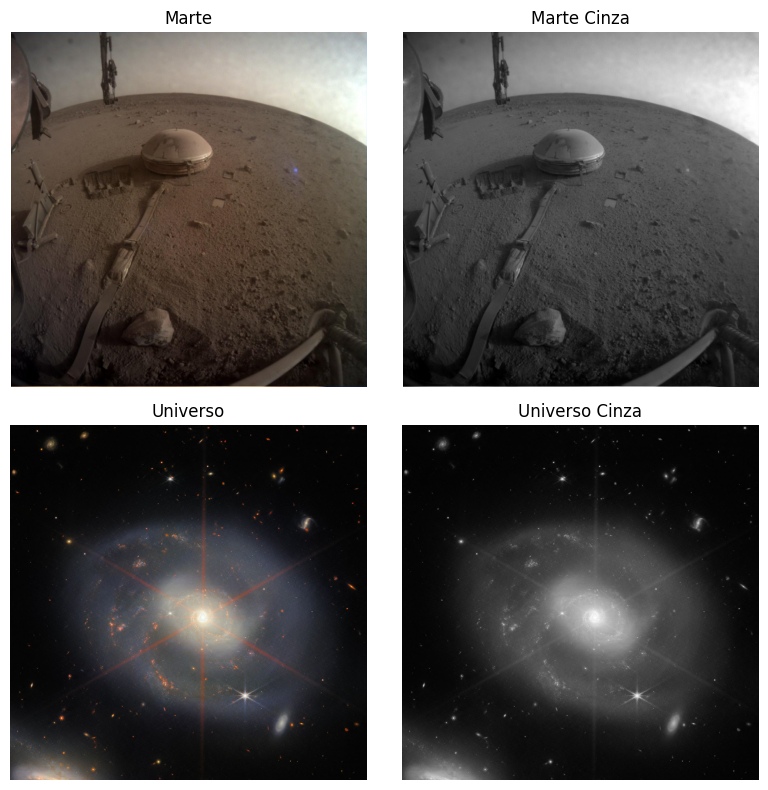

In [11]:
plt.rcParams['image.cmap'] = 'gray'

IMG1_PATH = Path('mars.jpg')
IMG2_PATH = Path('universe.jpg') 
OUT_DIR = Path('outputs')

def load_image(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Imagem não encontrada: {path.resolve()}')
    bgr = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if bgr is None:
        raise ValueError(f'Não foi possível ler a imagem: {path.resolve()}')
    if bgr.ndim == 2: 
        return bgr
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def to_gray(img):
    if img.ndim == 2: return img
    return (0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]).astype(np.float32)

def save_image(filename, img, out_dir=OUT_DIR):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / filename
    arr = np.clip(img, 0, 255).astype(np.uint8)
    if arr.ndim == 3:
        arr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(out_path), arr)
    return out_path

def show_grid(images, titles, cols, figsize=None):
    n = len(images)
    rows = (n + cols - 1) // cols
    
    if figsize is None:
        figsize = (cols * 4, rows * 4)
        
    _, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if n > 1 else [axes]
    
    for i in range(len(axes)):
        if i < n:
            axes[i].imshow(images[i], vmin=0, vmax=255)
            axes[i].set_title(titles[i])
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()
    
def initialize():
    mars = load_image(IMG1_PATH)
    mars_gray = to_gray(mars)
    universe = load_image(IMG2_PATH)
    universe_gray = to_gray(universe)
    
    save_image('mars_gray.jpg', mars_gray, '.')
    save_image('universe_gray.jpg', universe_gray, '.')
    show_grid([mars, mars_gray, universe, universe_gray], ['Marte', 'Marte Cinza', 'Universo', 'Universo Cinza'], cols=2)

initialize()

### Questão 1 

#### Funções auxiliares

In [12]:
def get_matrix_transpose(matrix):
    return matrix.T

def get_basis_matrix(N):
    T = np.zeros((N, N), dtype=np.float32)
    for u in range(N):
        for x in range(N):
            if u == 0:
                T[u, x] = 1.0 / np.sqrt(N)
            else:
                T[u, x] = np.sqrt(2.0 / N) * np.cos((2 * x + 1) * u * np.pi / (2.0 * N))
    return T

def dct(block, T, T_transposed):
    return T @ block @ T_transposed

def icdt(dct_block, T_transposed, T):
    return T_transposed @ dct_block @ T

def get_quantization_matrix(quality, quantization_matrix):
    if quality <= 0: quality = 1
    if quality > 100: quality = 100
    scale = (5000 / quality) if quality < 50 else (200 - 2 * quality)
    Q = np.floor((quantization_matrix * scale + 50) / 100)
    Q[Q == 0] = 1
    return Q.astype(np.float32)

def quantize(dct_block, Q):
    return np.round(dct_block / Q)

def dequantize(block_quant, Q):
    return block_quant * Q

#### Função orquestradora e de comparação

In [13]:
def compress(img_gray, quality, block_size):
    H, W = img_gray.shape
    H_new = H - (H % block_size)
    W_new = W - (W % block_size)
    img_trimmed = img_gray[:H_new, :W_new].copy()
    
    img_reconstructed = np.zeros_like(img_trimmed)
    img_quantized_coefficients = np.zeros_like(img_trimmed)
    
    T = get_basis_matrix(block_size)
    T_transposed = get_matrix_transpose(T)
    
    base_q_matrix = np.array([
        [16, 11, 10, 16,  24,  40,  51,  61],
        [12, 12, 14, 19,  26,  58,  60,  55],
        [14, 13, 16, 24,  40,  57,  69,  56],
        [14, 17, 22, 29,  51,  87,  80,  62],
        [18, 22, 37, 56,  68, 109, 103,  77],
        [24, 35, 55, 64,  81, 104, 113,  92],
        [49, 64, 78, 87, 103, 121, 120, 101],
        [72, 92, 95, 98, 112, 100, 103,  99]
    ], dtype=np.float32)
    
    Q = get_quantization_matrix(quality, base_q_matrix)
    
    for r in range(0, H_new, block_size):
        for c in range(0, W_new, block_size):
            block = img_trimmed[r:r+block_size, c:c+block_size]
            
            block_centered = block - 128.0
            
            block_dct = dct(block_centered, T, T_transposed)
            
            block_quant = quantize(block_dct, Q)
            img_quantized_coefficients[r:r+block_size, c:c+block_size] = block_quant
            
            block_dequant = dequantize(block_quant, Q)
            block_idct = icdt(block_dequant, T_transposed, T) 
            
            img_reconstructed[r:r+block_size, c:c+block_size] = block_idct + 128.0
            
    return img_trimmed, img_reconstructed, img_quantized_coefficients




def compress_evaluation(original, reconstructed, quantized_coefs):
    mse = np.mean((original - reconstructed) ** 2)
    psnr = 100.0 if mse == 0 else 10 * np.log10((255.0 ** 2) / mse)
    sparsity_pct = (np.sum(quantized_coefs == 0) / quantized_coefs.size) * 100
    
    return mse, psnr, sparsity_pct

#### Rodando

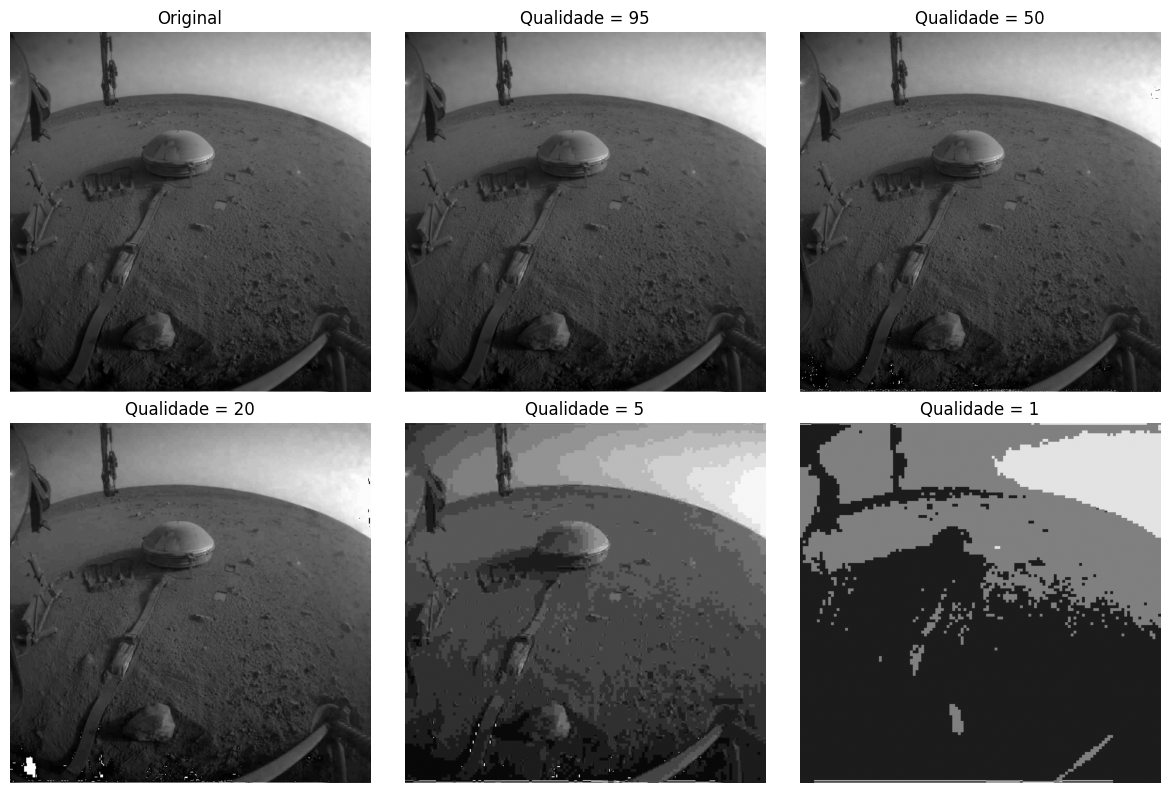

,Qualidade,MSE,PSNR,Sparsity
0,95,0.497266,51.164918,84.371758
1,50,7.480867,39.391284,89.315319
2,20,15.450534,36.241369,96.070957
3,5,47.672278,31.348145,98.244953
4,1,108.349358,27.782540,98.919392


In [ ]:

quality_values = [95, 50, 20, 5, 1]
results = []
block=8

mars_gray = load_image('mars_gray.jpg')
H, W = mars_gray.shape
orig_trimmed = mars_gray[:H-(H%block), :W-(W%block)]

reconstructed_images = [orig_trimmed]
titles = ['Original']

for q in quality_values:
    _, recon_img, coefs = compress(mars_gray, quality=q, block_size=block)

    mse, psnr, sparsity = compress_evaluation(orig_trimmed, recon_img, coefs)

    results.append({
        'Qualidade': q,
        'MSE': mse,
        'PSNR': psnr,
        'Sparsity': sparsity
    })

    reconstructed_images.append(recon_img)
    titles.append(f'Qualidade = {q}')

show_grid(reconstructed_images, titles, cols=3)

df_results = pd.DataFrame(results)
display(df_results)

#### Análise

O impacto visual das transformações nas imagens reconstruídas revela uma degradação progressiva conforme os níveis de compressão se tornam mais severos.

* **$Q = 95$ e $Q = 50$:** O algoritmo preserva uma fidelidade quase total em relação à imagem original. As perdas ficam restritas a detalhes texturais praticamente imperceptíveis. Mesmo na imagem de menor qualidade conseguimos identificar detalhes no céu e no solo.

* **($Q = 20$):** Mesmo sob uma compressão considerável, a imagem mantém integridade estrutural de seus principais elementos. Os contornos da sonda, a linha do horizonte e o solo continuam perfeitamente reconhecíveis. Contudo, as texturas perdem o aspecto natural e passam a exibir transições mais grosseiras e ruidosas. Começam a aparecer sinais de degradação na parte superior direita do horizonte e na parte inferior da figura.

* **$Q = 5$ a $Q = 1$:** Em $Q=5$, a pixelização se torna dominante na imagem. O colapso mais drástico do experimento ocorre justamente no salto de **$Q=5$ para $Q=1$**. No nível mais baixo ($Q=1$), a geometria e as formas dos objetos são completamente destruídas. O que resta na imagem são macroblocos sólidos de tons de cinza que apenas sinalizam as grandes massas de iluminação da cena (a região clara do céu ao fundo e o sombreamento geral do solo).

Um ponto interessante observado no grid é que as distorções se tornam evidentes primeiro na região do céu.

Além disso, um detalhe curioso de se notar no céu é a preservação do que aparenta ser um planeta localizado no canto esquerdo superior. Embora não haja resolução alguma para definir feições ou detalhes geométricos precisos, o algoritmo consegue delimitar que existe um corpo ou objeto ali

Os dados comparativos extraídos consolidam as análises visuais e revelam o fato de que existem dinâmicas na compressão que operam de forma puramente matemática antes de se manifestarem visualmente. Na transição de $Q=95$ para $Q=50$, a taxa de esparsidade passa de 84.37% para 89.31%. Ao reduzir para $Q=20$, essa taxa dá um salto expressivo e atinge **96.07%**. O ponto é que, visualmente,não se nota extrema diferença na qualidade das imagens $Q=50$ e $Q=20$. Isso demonstra a eliminação de redundâncias, o algoritmo limpou 96% dos dados da matriz sem causar um impacto destrutivo equivalente na imagem observada.
